# Overarching Exercise - The Bridge

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import scipy.stats



## Design of a concrete bridge

This exercise will focus on the design of a concrete bridge, where the variable of interest will be the total weight of the vehicles. This dataset has been retrieved from the Weight-in-Motion system from the Netherlands, which measures a number of characteristics of heavily loaded traffic in certain locations throughout the country. These are speed (km/h), vehicle length (m), load per axle (kN), and number of axles (-). As the probabilistic design engineer at your firm, you have been tasked with providing preliminary design parameters, which includes: defining the design values to be used for this design (Module I, defining boundary conditions); evaluating the reliability of the structure components (Module II, reliability analysis); and assessing the whole system reliability (Module III, risk assessment).

In [2]:
#lets load the data
loads = pd.read_csv('data\Overarching Exercise WIM Data.csv',header=None)

### Dataset processing: daily maximum loads

First, lets examine the statistics and distribution of the maximum daily loads. To do so, you need to set a high threshold to define which loads we consider as 'maximum'. Here, we are using the quantile function from numpy and the threshold is the 95th percentile (or 0.95 quantile). You can change the value and see yourself what happens.  

In [3]:
# Select random values
threshold = np.quantile(loads, 0.95)
N_data = len(loads)

# Sample maxima with threshold
W = loads[loads > threshold]

## dropping annoying NaN's
W = W.dropna()
W_t = W - threshold

Lets see now some characteristic values of the distribution of the maxima. Enter your code to see the minima, the maximum, the mean and the median and then the table will automatically be updated.

In [4]:
#enter your code here

minimum = np.min(W)
maximum = np.max(W)
mean = np.mean(W)
median = np.median(W)
mode = np.array(W.mode()[0][0])
std = np.std(W[0])

```{admonition} Solution
:class: tip, dropdown
This is only one way to calculate the above:

minimum = np.min(W)
maximum = np.max(W)
mean = np.mean(W)
median = np.median(W)
mode = np.array(W.mode()[0][0])
std = np.std(W[0])
```

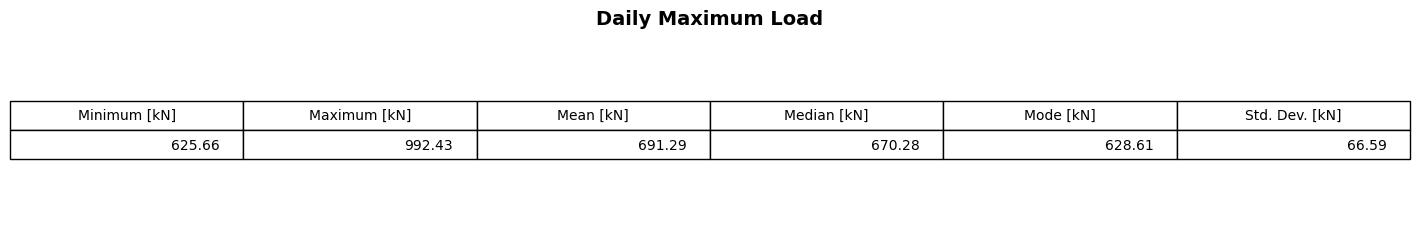

In [5]:
## code for making the table
columns = ['Minimum [kN]', 'Maximum [kN]', 'Mean [kN]', 'Median [kN]', 'Mode [kN]',
        'Std. Dev. [kN]']
data = [[f'{minimum:.2f}', f'{maximum:.2f}', 
         f'{mean:.2f}', f'{median:.2f}', 
         f'{mode:.2f}', f'{std:.2f}']]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 3))  # You can adjust the figure size as needed

# Hide the axes
ax.xaxis.set_visible(False) 
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

ax.set_title('Daily Maximum Load', fontsize=14, fontweight='bold', pad=0)
# Create the table
table = ax.table(cellText=data, colLabels=columns, loc='center')

# Adjust cell sizes
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjust the scaling of the cells
table.scale(2, 2)  # Scale width by 2 and height by 2 (you can adjust these values)

# Adjust layout
plt.subplots_adjust(left=0.2, bottom=0.2)

# Show the table
plt.show()

*What does this information tell you about the daily maximum load on the bridge? Is the data set skewed? Plot or sketch a histogram of the data. What is the typical load you would expect on a single day? Why?*

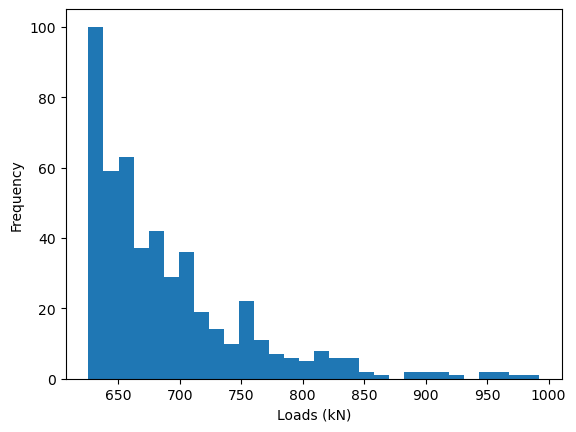

In [6]:
plt.hist(W,bins=30);
plt.xlabel('Loads (kN)')
plt.ylabel('Frequency')
plt.show()

Rank the data and determine the empirical CDF for daily maximum load. 

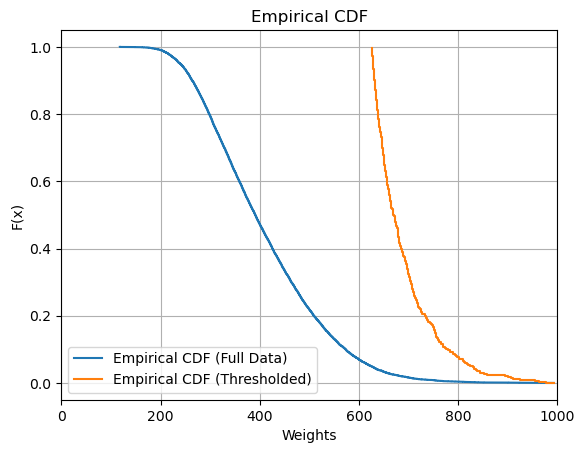

In [58]:
# Empirical Complementary CDF
ecdf_full = ECDF(np.array(loads).flatten())
[f0, x0] = 1 - ecdf_full.y, ecdf_full.x

# Thresholded Complementary Empirical CDF
ecdf_thresh = ECDF(np.array(W_t).flatten())
[f, x] = 1 - ecdf_thresh.y, ecdf_thresh.x

# Plot empirical CDF
plt.figure()
plt.title('Empirical CDF')
plt.xlim([0, 1000])

# Plot full data CDF using the plt.step function
plt.step(x0, f0, linewidth=1.5, label='Empirical CDF (Full Data)')

# Uncomment the next lines to include the thresholded CDF
plt.step(x + threshold, f, linewidth=1.5, label='Empirical CDF (Thresholded)')

plt.xlabel('Weights')
plt.ylabel('F(x)')
plt.legend()
plt.grid(True)
plt.show()


Choose a parametric probability distribution model to fit the daily maximum load data – this will allow you to assess the relative frequency of the daily maxima, as well as make an assessment on rarer events (you can use scipy.stats.<distribution> to do so by replacing <distribution> by the distribution type you want to fit ). 

Shape: 0.923914853709892, Location: 0.9800000000000181, Scale: 60.58726445153576


C:\Users\chari\AppData\Local\Temp\ipykernel_16496\1684607480.py:16: RuntimeWarning: divide by zero encountered in log10
  plt.step(x, np.log10(f), linewidth=1.5, label='Empirical CDF (Thresholded)')


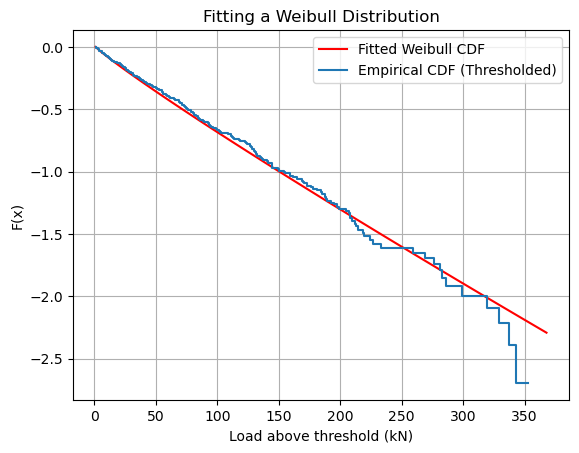

In [ ]:
shape, loc, scale = scipy.stats.weibull_min.fit(np.array(W_t))  # Shape, location, and scale parameters
print(f"Shape: {shape}, Location: {loc}, Scale: {scale}")

# Generate the fitted PDF
x_weib = np.linspace(min(np.array(W_t)), max(np.array(W_t)), 100)
cdf = scipy.stats.weibull_min.cdf(x_weib, c=shape, loc=loc, scale=scale)

# Plot the data and fitted Weibull CDF

plt.plot(x_weib, np.log10(1- cdf), label="Fitted Weibull CDF", color="red")

plt.grid()
plt.title("Fitting a Weibull Distribution")

# Plot full data CDF
plt.step(x, np.log10(f), linewidth=1.5, label='Empirical CDF (Thresholded)')
plt.legend()
plt.ylabel('F(x)')
plt.xlabel('Load above threshold (kN)')
plt.show()

```{admonition} Solution
:class: tip, dropdown

Fitting a Weibull distribution to the loads data:

<code> shape, loc, scale = scipy.stats.weibull_min.fit(np.array(W_t))  # Shape, location, and scale parameters
print(f"Shape: {shape}, Location: {loc}, Scale: {scale}")</code>  

# Generate the fitted PDF
x_weib = np.linspace(min(np.array(W_t)), max(np.array(W_t)), 100)
cdf = scipy.stats.weibull_min.cdf(x_weib, c=shape, loc=loc, scale=scale)

# Plot the data and fitted Weibull CDF

plt.plot(x_weib, 1- cdf, label="Fitted Weibull CDF", color="red")

plt.grid()
plt.title("Fitting a Weibull Distribution")

# Plot full data CDF
plt.step(x, f, linewidth=1.5, label='Empirical CDF (Thresholded)')
plt.legend()
plt.ylabel('F(x)')
plt.xlabel('Load above threshold (kN)')
plt.show()
```